In [1]:
# ==========================================================
# MONKEYPOX DATA PREPARATION
# SECTION 1 : IMPORT LIBRARIES
# ==========================================================

import os
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("="*70)
print("MONKEYPOX DATA PREPARATION")
print("="*70)

MONKEYPOX DATA PREPARATION


In [2]:
# ==========================================================
# SECTION 2 : DOWNLOAD DATASET FROM KAGGLE
# ==========================================================

!pip -q install kaggle

from google.colab import files

print("="*70)
print("UPLOAD kaggle.json")
print("="*70)

uploaded = files.upload()

UPLOAD kaggle.json


Saving kaggle.json to kaggle.json


In [3]:
# ==========================================================
# SECTION 3 : DOWNLOAD & EXTRACT DATASET
# ==========================================================

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20

!unzip -q mpox-skin-lesion-dataset-version-20-msld-v20.zip -d /content/

print("="*70)
print("DATASET DOWNLOADED SUCCESSFULLY")
print("="*70)

Dataset URL: https://www.kaggle.com/datasets/joydippaul/mpox-skin-lesion-dataset-version-20-msld-v20
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 567M/567M [00:04<00:00, 133MB/s]

DATASET DOWNLOADED SUCCESSFULLY


In [4]:
# ==========================================================
# SECTION 4 : DATASET PATH
# ==========================================================

DATASET_PATH = "/content/Original Images/Original Images/FOLDS/fold1"

TRAIN_PATH = os.path.join(DATASET_PATH, "Train")
VALID_PATH = os.path.join(DATASET_PATH, "Valid")
TEST_PATH  = os.path.join(DATASET_PATH, "Test")

print("="*70)
print("DATASET PATH")
print("="*70)

print(DATASET_PATH)

print("\nExists :", os.path.exists(DATASET_PATH))

DATASET PATH
/content/Original Images/Original Images/FOLDS/fold1

Exists : True


In [5]:
# ==========================================================
# SECTION 5 : VERIFY DATASET STRUCTURE
# ==========================================================

print("="*70)
print("TRAIN CLASSES")
print("="*70)

classes = sorted(os.listdir(TRAIN_PATH))

for cls in classes:
    print(cls)

TRAIN CLASSES
Chickenpox
Cowpox
HFMD
Healthy
Measles
Monkeypox


In [6]:
# ==========================================================
# SECTION 6 : COUNT IMAGES
# ==========================================================

print("="*70)
print("MONKEYPOX DATASET INFORMATION")
print("="*70)

train_total = 0
valid_total = 0
test_total = 0

for cls in classes:

    train_count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    valid_count = len(os.listdir(os.path.join(VALID_PATH, cls)))
    test_count  = len(os.listdir(os.path.join(TEST_PATH, cls)))

    train_total += train_count
    valid_total += valid_count
    test_total += test_count

    print(f"{cls:<20} Train:{train_count:4}   Valid:{valid_count:4}   Test:{test_count:4}")

print("="*70)
print("TOTAL TRAIN :", train_total)
print("TOTAL VALID :", valid_total)
print("TOTAL TEST  :", test_total)
print("TOTAL IMAGES:", train_total + valid_total + test_total)
print("="*70)

MONKEYPOX DATASET INFORMATION
Chickenpox           Train:  50   Valid:  16   Test:   9
Cowpox               Train:  49   Valid:  10   Test:   7
HFMD                 Train: 116   Valid:  29   Test:  16
Healthy              Train:  83   Valid:  22   Test:   9
Measles              Train:  37   Valid:  12   Test:   6
Monkeypox            Train: 202   Valid:  55   Test:  27
TOTAL TRAIN : 537
TOTAL VALID : 144
TOTAL TEST  : 74
TOTAL IMAGES: 755


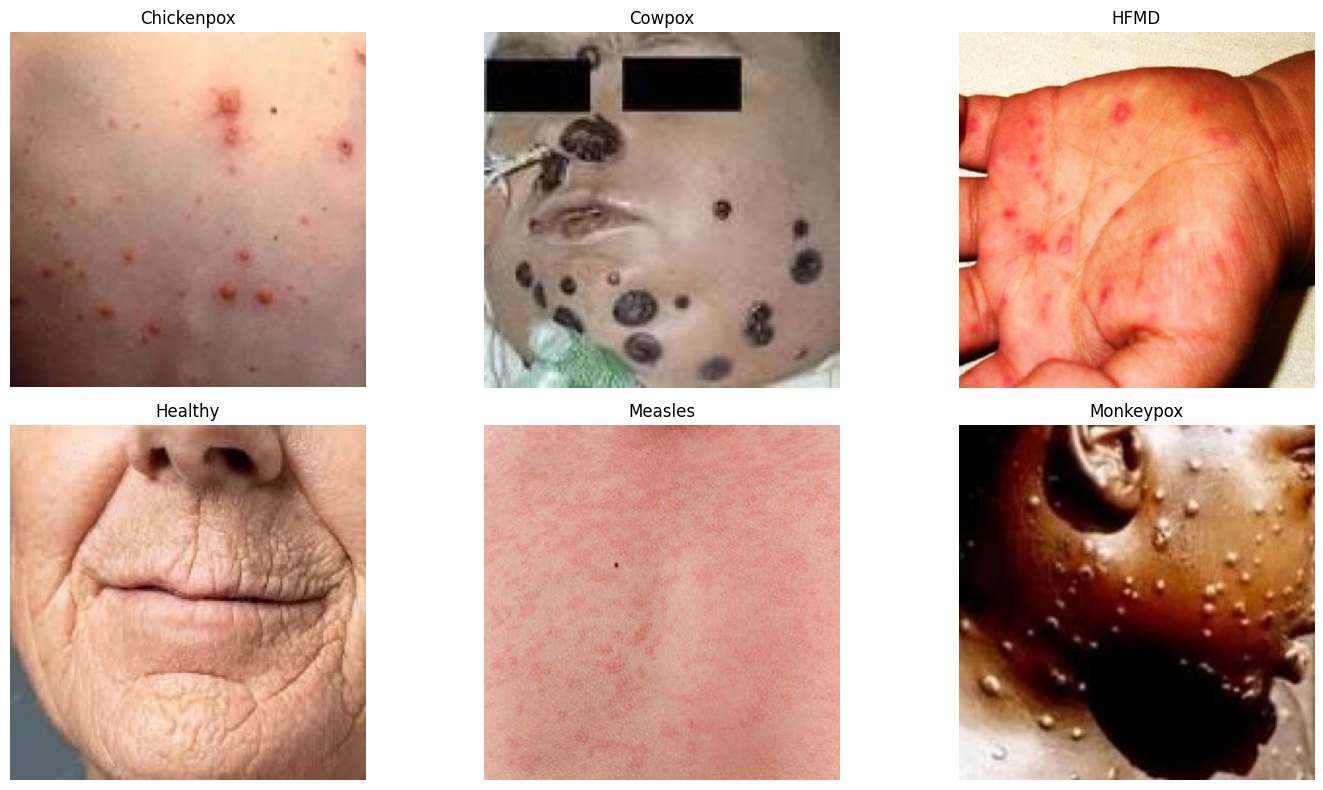

In [7]:
# ==========================================================
# SECTION 7 : VISUALIZE SAMPLE IMAGES
# ==========================================================

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    img_name = random.choice(os.listdir(os.path.join(TRAIN_PATH, cls)))

    img_path = os.path.join(TRAIN_PATH, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# SECTION 8 : IMAGE SIZE INFORMATION
# ==========================================================

print("="*70)
print("IMAGE SIZE INFORMATION")
print("="*70)

for cls in classes:

    img_name = random.choice(os.listdir(os.path.join(TRAIN_PATH, cls)))

    img_path = os.path.join(TRAIN_PATH, cls, img_name)

    img = Image.open(img_path)

    print(f"{cls:<20} {img.size}")

IMAGE SIZE INFORMATION
Chickenpox           (224, 224)
Cowpox               (71, 71)
HFMD                 (200, 200)
Healthy              (224, 224)
Measles              (224, 224)
Monkeypox            (224, 224)


In [9]:
# ==========================================================
# SECTION 9 : DATASET SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Class": classes,

    "Train": [len(os.listdir(os.path.join(TRAIN_PATH,c))) for c in classes],

    "Validation": [len(os.listdir(os.path.join(VALID_PATH,c))) for c in classes],

    "Test": [len(os.listdir(os.path.join(TEST_PATH,c))) for c in classes]

})

summary["Total"] = summary["Train"] + summary["Validation"] + summary["Test"]

summary

,Class,Train,Validation,Test,Total
0,Chickenpox,50,16,9,75
1,Cowpox,49,10,7,66
2,HFMD,116,29,16,161
3,Healthy,83,22,9,114
4,Measles,37,12,6,55
5,Monkeypox,202,55,27,284


In [10]:
# ==========================================================
# SECTION 10 : NOTEBOOK COMPLETED
# ==========================================================

print("="*70)
print("MONKEYPOX DATA PREPARATION COMPLETED SUCCESSFULLY")
print("="*70)

print("\nDataset Ready For Preprocessing.")

MONKEYPOX DATA PREPARATION COMPLETED SUCCESSFULLY

Dataset Ready For Preprocessing.
